# Teacher $P_{avg}$ comparison plots

Genera una única figura (grilla de subplots 2x5) a partir de las tablas
`agnews/teacher_avg_comparison_table.md` e `imdb/teacher_avg_comparison_table.md`.
Filas = dataset (AG News, IMDB). Columnas = métrica. Eje X de cada subplot: capa $i$.
La figura se guarda en `images/teacher_avg_comparisons/teacher_avg_comparison_grid.png`
(300 dpi) y también se muestra inline.

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# IEEE template: figure labels in 8pt Times New Roman, to match the body text font.
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["mathtext.fontset"] = "stix"  # visually matches Times for $...$ labels

ROOT = Path.cwd()
OUT_DIR =  ROOT / "images"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TABLES = {
    "IMDb": ROOT / "imdb" / "teacher_avg_comparison_table.md",
    "AG News": ROOT / "agnews" / "teacher_avg_comparison_table.md",
}


In [2]:
def parse_md_table(path):
    """Parse the single-table markdown files produced for the P_avg comparison."""
    lines = [l for l in Path(path).read_text(encoding="utf-8").splitlines() if l.strip().startswith("|")]

    header = [c.strip() for c in lines[0].strip("|").split("|")]
    rows = [[c.strip() for c in l.strip("|").split("|")] for l in lines[2:]]  # skip header + separator

    df = pd.DataFrame(rows, columns=header)
    df = df.rename(columns={"Layer $i$": "Layer"})
    df["Layer"] = df["Layer"].astype(int)

    metric_cols = [c for c in df.columns if c not in ("Model", "Layer")]
    for col in metric_cols:
        df[col] = pd.to_numeric(df[col].replace("–", pd.NA), errors="coerce")

    return df, metric_cols


In [3]:
frames = []
metric_cols = None
for dataset, path in TABLES.items():
    df, metric_cols = parse_md_table(path)
    df.insert(0, "Dataset", dataset)
    frames.append(df)

data = pd.concat(frames, ignore_index=True)
data.head()


,Dataset,Model,Layer,Cosine Similarity,Frobenius Distance,$D_{JS}$,PR,ER
0,IMDb,Teacher $P_{avg}$,0,NaN,NaN,NaN,3.2614,309.3200
1,IMDb,Teacher $P_{avg}$,1,NaN,NaN,NaN,1.0108,42.2246
2,IMDb,Teacher $P_{avg}$,2,NaN,NaN,NaN,1.0004,5.2036
3,IMDb,Teacher $P_{avg}$,3,NaN,NaN,NaN,1.0006,6.9923
4,IMDb,Teacher $P_{avg}$,4,NaN,NaN,NaN,1.0036,20.3665


In [6]:
# Fixed model -> style mapping (identity follows the entity across every subplot).
# Colors are the categorical slots from the project palette, in fixed order;
# Teacher P_avg is a muted dashed reference line rather than a competing series.
# Data-column keys stay as the raw table's Model names; "label" is the display
# name used in the legend (S_0 = Bad Student, S_1 = Student, S_2 = Student Local).
STYLE = {
    "Teacher $P_{avg}$": dict(color="#898781", linestyle="--", marker="x", label="Teacher $P_{avg}$"),
    "Baseline":          dict(color="#2a78d6", linestyle="-",  marker="o", label="Baseline"),
    "Bad Student":       dict(color="#008300", linestyle="-",  marker="s", label="$S_0$"),
    "Student":           dict(color="#e87ba4", linestyle="-",  marker="^", label="$S_1$"),
    "Student Local":     dict(color="#eda100", linestyle="-",  marker="D", label="$S_2$"),
    "Pure Student":      dict(color="#ed2f00", linestyle="-",  marker="D", label="$S_3$"),
}

MODEL_ORDER = list(STYLE.keys())
DATASET_ORDER = list(TABLES.keys())


C:\Users\Usuario\AppData\Local\Temp\ipykernel_13656\738237936.py:63: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(rect=[0, 1, 1, 1])


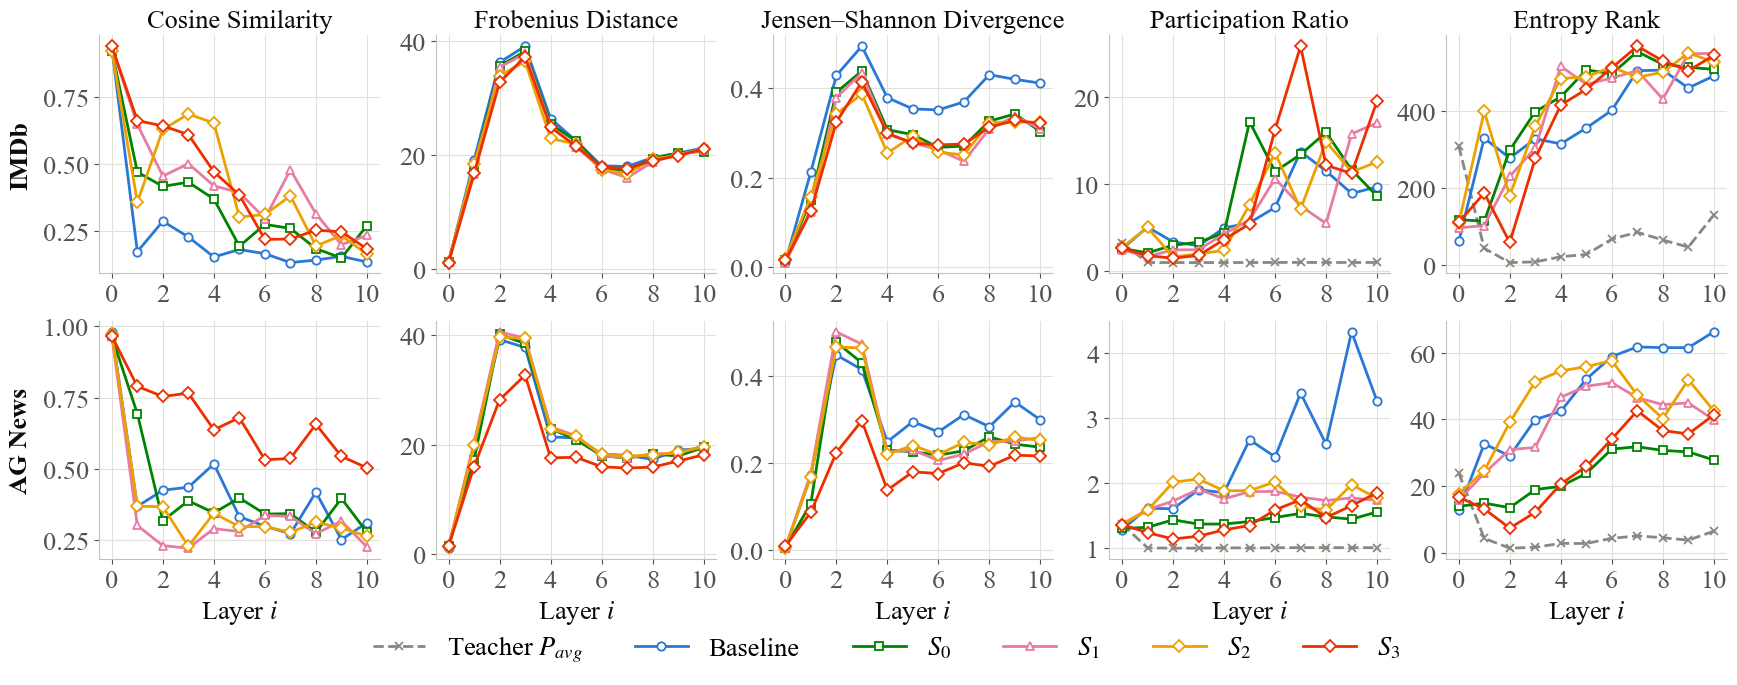

Saved c:\Users\Usuario\Desktop\posgrado\XAI\Proyecto\Proyecto_XAI\images\teacher_avg_comparison_grid.png


In [7]:
n_rows, n_cols = len(DATASET_ORDER), len(metric_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.4 * n_rows))

# IEEE figure-label convention: titles must be words, not bare symbols/abbreviations.
DISPLAY_TITLES = {
    "$D_{JS}$": "Jensen–Shannon Divergence",
    "PR": "Participation Ratio",
    "ER": "Entropy Rank",
}

LABEL_FONTSIZE = 19  # IEEE template: 8pt for figure labels

for i, dataset in enumerate(DATASET_ORDER):
    sub_all = data[data["Dataset"] == dataset]

    for j, metric in enumerate(metric_cols):
        ax = axes[i, j]

        for model in MODEL_ORDER:
            sub = sub_all[sub_all["Model"] == model].sort_values("Layer")
            if sub[metric].isna().all():
                continue
            style = STYLE[model]
            ax.plot(
                sub["Layer"], sub[metric],
                color=style["color"],
                linestyle=style["linestyle"],
                marker=style["marker"],
                linewidth=2,
                markersize=6,
                markerfacecolor="white",
                markeredgewidth=1.3,
            )

        ax.set_xticks(range(0, 11, 2))
        ax.grid(True, color="#e1e0d9", linewidth=0.8)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)
        for spine in ("left", "bottom"):
            ax.spines[spine].set_color("#c3c2b7")
        ax.tick_params(colors="#52514e", labelsize=LABEL_FONTSIZE)

        if i == 0:
            ax.set_title(DISPLAY_TITLES.get(metric, metric), color="#0b0b0b", fontsize=LABEL_FONTSIZE)
        if i == n_rows - 1:
            ax.set_xlabel("Layer $i$", color="#0b0b0b", fontsize=LABEL_FONTSIZE)
        if j == 0:
            ax.set_ylabel(dataset, color="#0b0b0b", fontsize=LABEL_FONTSIZE, fontweight="bold", labelpad=8)

# Single shared legend (model -> style is fixed across every subplot).
legend_handles = [
    Line2D(
        [0], [0], color=style["color"], linestyle=style["linestyle"], marker=style["marker"],
        markerfacecolor="white", markeredgewidth=1.3, linewidth=2, label=style["label"],
    )
    for style in STYLE.values()
]
fig.legend(
    handles=legend_handles, loc="lower center", ncol=len(STYLE),
    frameon=False, fontsize=LABEL_FONTSIZE, bbox_to_anchor=(0.5, -0.08),
)

fig.tight_layout(rect=[0, 1, 1, 1])

out_path = OUT_DIR / "teacher_avg_comparison_grid.png"
fig.savefig(out_path, dpi=300, facecolor="white", bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")
